In [1]:
# libararies

# Tensorflow 2
import tensorflow as tf
from tensorflow import keras
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import GaussianNoise, Dropout


from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten


import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib inline  

from PIL import Image
import glob

import os
import random
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score

from tensorflow.keras.models import Model

from tf_keras_vis.saliency import Saliency
from tf_keras_vis.utils import normalize

from tf_keras_vis.saliency import Saliency
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus
from tf_keras_vis.scorecam import Scorecam
from tf_keras_vis.activation_maximization import ActivationMaximization
from tf_keras_vis.activation_maximization.callbacks import Progress
from tf_keras_vis.activation_maximization.input_modifiers import Jitter, Rotate2D
from tf_keras_vis.activation_maximization.regularizers import TotalVariation2D, Norm
from tf_keras_vis.utils.model_modifiers import ExtractIntermediateLayer, ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore


# original (wxh) is (800x600)
w = 224
h = 224

# fix random seed for reproducibility
SEED = 42

# limiting mem size
import tensorflow as tf
tf.config.optimizer.set_jit(False)
# Enable memory growth to prevent TensorFlow from allocating all GPU memory at once
physical_devices = tf.config.list_physical_devices('GPU')
# Limit memory to a certain fraction (e.g., 4GB of GPU memory)
gpu_memory_limit = 8192 # in MB, but week day 750 in MB
for device in physical_devices:
    tf.config.set_logical_device_configuration(
        device,
        [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=gpu_memory_limit)]
    )

2026-07-26 19:49:18.834501: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-26 19:49:18.883568: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-26 19:49:19.653129: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:

# Load data
X =[]
Y =[]

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'} # this will account for all image extensions though we are only using .jpg

def list_images(folder):
    # case-insensitive, any extension in IMG_EXTS
    return [os.path.join(folder, f) for f in os.listdir(folder)
            if os.path.splitext(f)[1].lower() in IMG_EXTS]

for filename in list_images('train/Healthy'):
    im = Image.open(filename).convert('RGB')
    im = im.resize((w, h), Image.LANCZOS)
    arr = np.array(im)

    # add images and class to the two lists
    X.append(arr)
    Y.append(0)  # Healthy class

# same below
for filename in list_images('train/aculus_olearius'):
    im = Image.open(filename).convert('RGB')
    im = im.resize((w, h), Image.LANCZOS)
    arr = np.array(im)

    X.append(arr)
    Y.append(1)  # aculus_olearius class

for filename in list_images('train/olive_peacock_spot'):
    im = Image.open(filename).convert('RGB')
    im = im.resize((w, h), Image.LANCZOS)
    arr = np.array(im)

    X.append(arr)
    Y.append(2)  # olive_peacock_spot class


    
# Convert to NP array
X = np.array(X)


# reshape to be [samples][channels][width][height]
X = X.reshape(X.shape[0], w, h, 3).astype('float32')

# Normalize the data
X = X /255

# one hot encode outputs
Y = np.array(Y)

# randomize the data set - numpy arrays
randomize = np.arange(len(X))
np.random.shuffle(randomize)
X = X[randomize]
Y = Y[randomize]


Y = to_categorical(Y)
num_classes = Y.shape[1]

print("X:", X.shape, "| Y:", Y.shape, "| per-class:", Y.sum(axis=0))

X: (2720, 224, 224, 3) | Y: (2720, 3) | per-class: [ 830.  690. 1200.]


Healthy: 830, Aculus Olearius: 690, Olive Peacock Spot: 1200


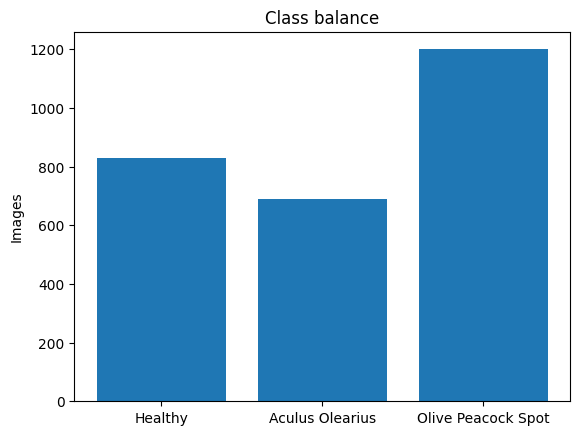

In [3]:
# Class representation

healthy_class = Y[:, 0] == 1
aculusOlearius_class = Y[:, 1] == 1
olivePeacockSpot_class = Y[:, 2] == 1
print(f"Healthy: {healthy_class.sum()}, Aculus Olearius: {aculusOlearius_class.sum()}, Olive Peacock Spot: {olivePeacockSpot_class.sum()}")

plt.bar(['Healthy', 'Aculus Olearius', 'Olive Peacock Spot'], [healthy_class.sum(), aculusOlearius_class.sum(), olivePeacockSpot_class.sum()])
plt.title('Class balance')
plt.ylabel('Images')
plt.show()

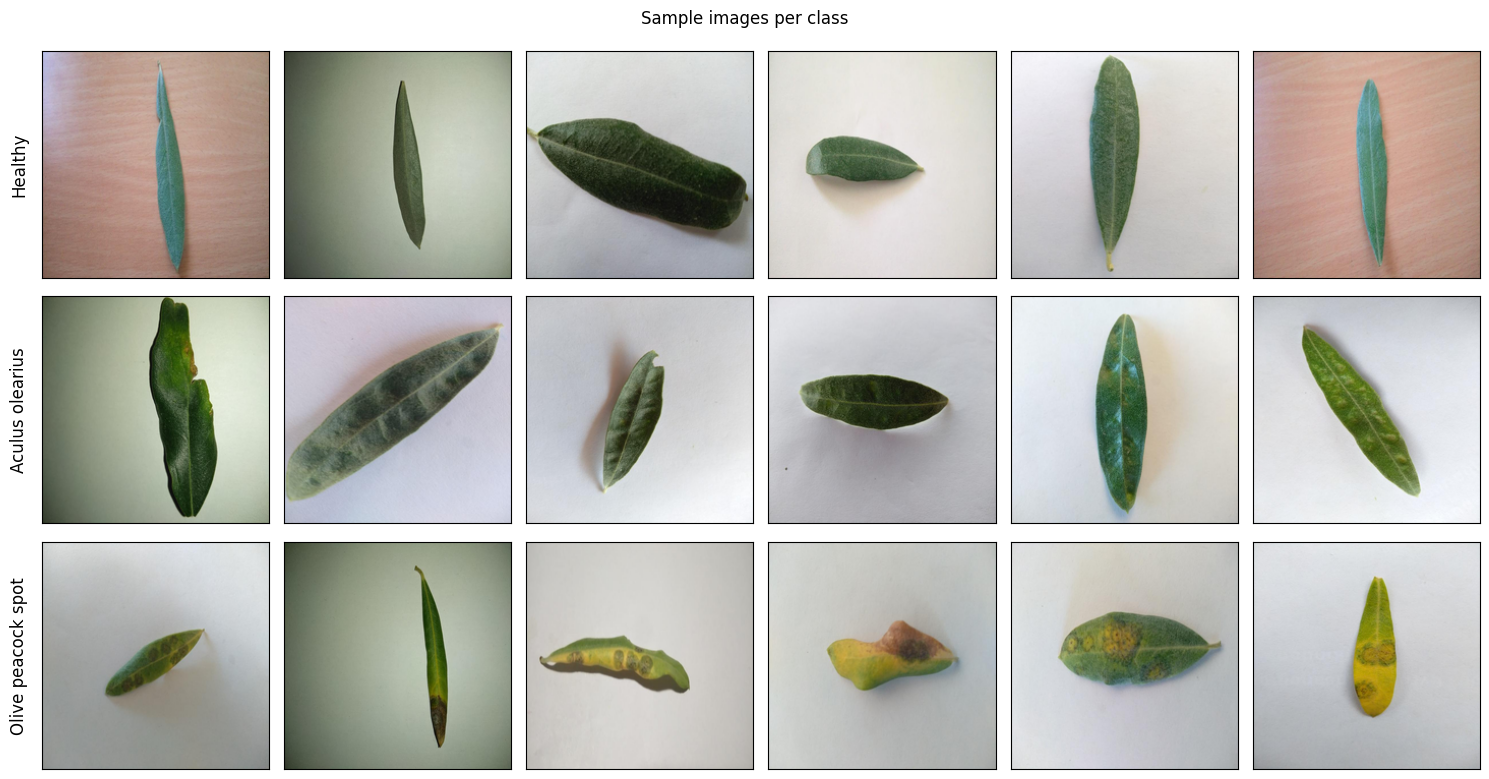

In [4]:
# Sample images per class
class_names = ['Healthy', 'Aculus olearius', 'Olive peacock spot']

# boolean mask per class from one-hot Y  (Y.argmax(1) gives the int label)
y_int = Y.argmax(axis=1)
masks = [y_int == 0, y_int == 1, y_int == 2]

fig, axes = plt.subplots(3, 6, figsize=(15, 8))
for row, (mask, name) in enumerate(zip(masks, class_names)):
    for i, idx in enumerate(np.where(mask)[0][:6]):
        ax = axes[row, i]
        ax.imshow(X[idx])
        ax.set_xticks([]); ax.set_yticks([])   # hide ticks but KEEP the frame
        if i == 0:
            ax.set_ylabel(name, fontsize=12, rotation=90, labelpad=10)

plt.suptitle('Sample images per class')
plt.tight_layout()
plt.show()

In [2]:
# batch processing time!

train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=10, zoom_range=0.1,
    width_shift_range=0.1, height_shift_range=0.1,
    horizontal_flip=True, vertical_flip=True, validation_split=0.3)
val_datagen  = ImageDataGenerator(rescale=1./255, validation_split=0.3)
test_datagen = ImageDataGenerator(rescale=1./255)

CLASSES = ['Healthy', 'aculus_olearius', 'olive_peacock_spot']

train_gen = train_datagen.flow_from_directory('train', target_size=(w, h),
                batch_size=32, class_mode='categorical', classes=CLASSES,
                subset='training', shuffle=True, seed=SEED)
val_gen   = val_datagen.flow_from_directory('train', target_size=(w, h),
                batch_size=32, class_mode='categorical', classes=CLASSES,
                subset='validation', shuffle=False, seed=SEED)
test_gen  = test_datagen.flow_from_directory('test', target_size=(w, h),
                batch_size=32, class_mode='categorical', classes=CLASSES,
                shuffle=False, seed=SEED)

num_classes = len(CLASSES)

Found 1904 images belonging to 3 classes.
Found 816 images belonging to 3 classes.
Found 680 images belonging to 3 classes.


In [3]:
# confirm rescale is good

xb, yb = next(train_gen)
print(xb.min(), xb.max())

6.342434e-05 1.0


### Pre-processing Conclusion
The original image width before import is wxh of 800x600 pixels. To load our images, we kept all the extensions incase any of the images within the folders of train/test were not <b>.jpg</b> then we had to lower the lower the extension name to deal with an import issue we experienced of mismatched cases.
- Due to the fact we are dealing with images of leaves and we are trying to get the best leaves the best information in the batch, we had to ensure we keep color as a factor because the different states of the Olive leaves is also greatly brought forward by the color
- We also looked into the class imbalance of the dataset and in ranking order:
    1. Olive Peacock Spot had the most images at 1,200 images
    2. Healthy class had 830 images
    3. Aculus Olearius had 690 images

<b>NB:</b> We are aware the model will most likely be better at predicting the most common class,but with reference to what our lecturer, Keith Quille, mentioned that making synthetic data is undesirable and we would need to give a good reason as to why we would downsize our samples to equal the least represented data. For now, we let the imbalance exist with hope of getting more data in future or potentially bringing more of the test images to the train to balance the quantity

- We viewed a sample of 6 images in each class and we can see they come in different sizes and even orientation, hence, will need to be considered when training.
- To prepare our data for training, validation, and testing, batch processing was our best implementation strategy because we are working with quite a few images and we would like to avoid running into a OOM error
- The images were resized to 224x224, we though 64x64 would be too small and based on previously done research, this was a size that maintained a good chunk of the data on the image
- The steps done:
    1. Splitting the train/test folders into 3 datagen: train, val, test
    2. Train gen was rescaled so that we can have a small scale and avoid huge gradients and the training oscilating wildly
    3. The images then had a horizontal and vertical flip because we want to train the model so that it can see images in all forms
    4. Train/Val of 70/30
    5. With the power of the DSS we went with 32 in batch size with hopes it can understand the data more when it looks at more images per weight update


Epoch 1/500


2026-07-26 21:44:22.748303: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


60/60 [==============================] - ETA: 0s - loss: 1.7246 - acc: 0.4863

2026-07-26 21:44:42.506861: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


60/60 [==============================] - 22s 344ms/step - loss: 1.7246 - acc: 0.4863 - val_loss: 0.9485 - val_acc: 0.5343 - lr: 0.0010
Epoch 2/500
60/60 [==============================] - 21s 348ms/step - loss: 0.7391 - acc: 0.6775 - val_loss: 0.9402 - val_acc: 0.6005 - lr: 0.0010
Epoch 3/500
60/60 [==============================] - 20s 341ms/step - loss: 0.6680 - acc: 0.7001 - val_loss: 1.0343 - val_acc: 0.6017 - lr: 0.0010
Epoch 4/500
60/60 [==============================] - 21s 342ms/step - loss: 0.5927 - acc: 0.7458 - val_loss: 0.9049 - val_acc: 0.6017 - lr: 0.0010
Epoch 5/500
60/60 [==============================] - 20s 337ms/step - loss: 0.5767 - acc: 0.7563 - val_loss: 0.9375 - val_acc: 0.5968 - lr: 0.0010
Epoch 6/500
60/60 [==============================] - 21s 342ms/step - loss: 0.5747 - acc: 0.7547 - val_loss: 0.9210 - val_acc: 0.6287 - lr: 0.0010
Epoch 7/500
60/60 [==============================] - 21s 348ms/step - loss: 0.5409 - acc: 0.7894 - val_loss: 0.8691 - val_acc: 0.6

...

60/60 [==============================] - ETA: 0s - loss: 1.0454 - acc: 0.5074

2026-07-26 22:31:33.432917: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


60/60 [==============================] - 23s 351ms/step - loss: 1.0454 - acc: 0.5074 - val_loss: 0.9168 - val_acc: 0.4902 - lr: 0.0010
Epoch 2/500
60/60 [==============================] - 21s 345ms/step - loss: 0.7190 - acc: 0.6345 - val_loss: 0.8777 - val_acc: 0.4975 - lr: 0.0010
Epoch 3/500
60/60 [==============================] - 20s 334ms/step - loss: 0.7229 - acc: 0.6439 - val_loss: 1.1190 - val_acc: 0.5588 - lr: 0.0010
Epoch 4/500
60/60 [==============================] - 21s 343ms/step - loss: 0.6780 - acc: 0.6812 - val_loss: 0.8644 - val_acc: 0.5882 - lr: 0.0010
Epoch 5/500
60/60 [==============================] - 20s 338ms/step - loss: 0.6252 - acc: 0.7201 - val_loss: 0.9828 - val_acc: 0.5833 - lr: 0.0010
Epoch 6/500
60/60 [==============================] - 20s 341ms/step - loss: 0.6290 - acc: 0.7122 - val_loss: 1.1082 - val_acc: 0.6091 - lr: 0.0010
Epoch 7/500
60/60 [==============================] - 20s 333ms/step - loss: 0.5941 - acc: 0.7463 - val_loss: 1.0043 - val_acc: 0.5

2026-07-26 22:37:43.588780: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]
2026-07-26 22:37:45.656107: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


26/26 [==============================] - 2s 69ms/step
>> T8_deep_wide_dense: val_loss=0.8644 val_acc=0.5882


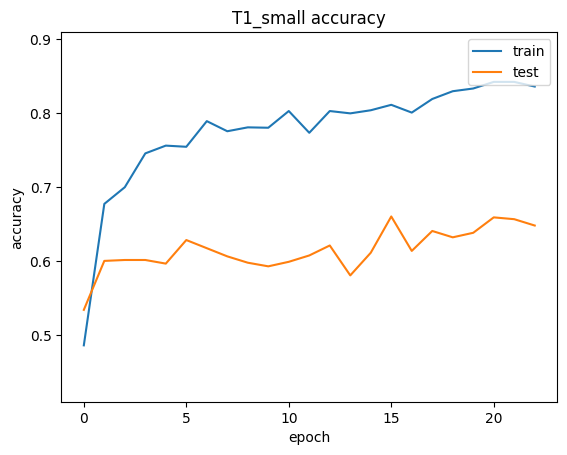

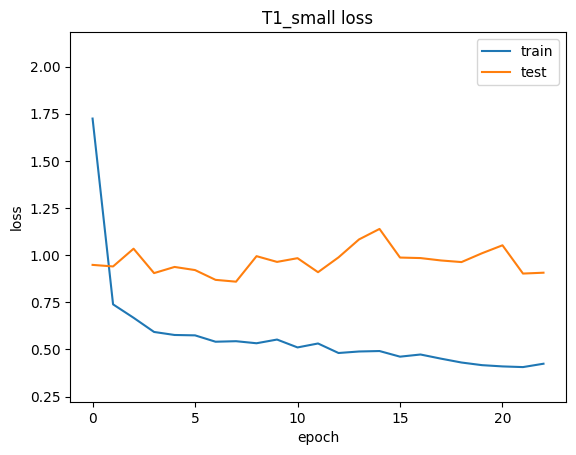

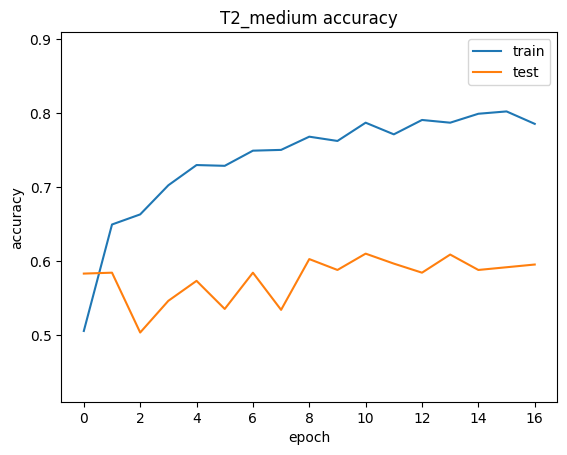

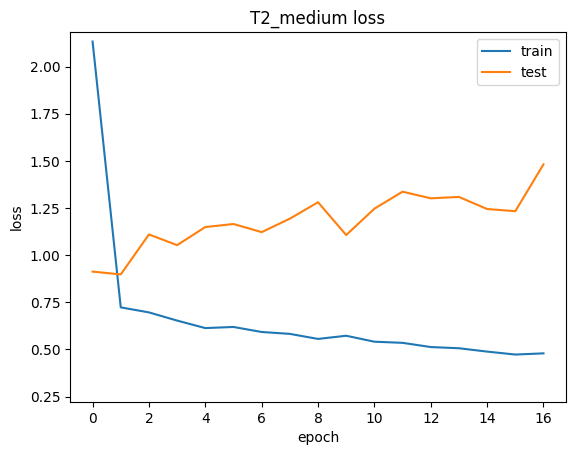

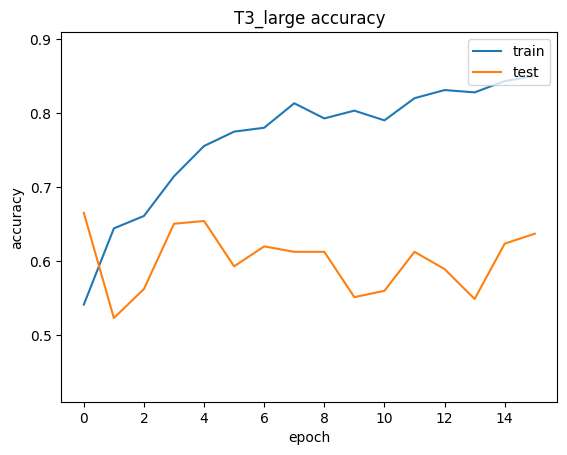

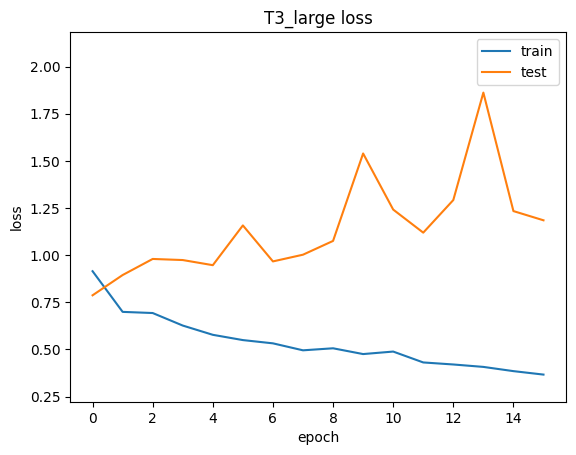

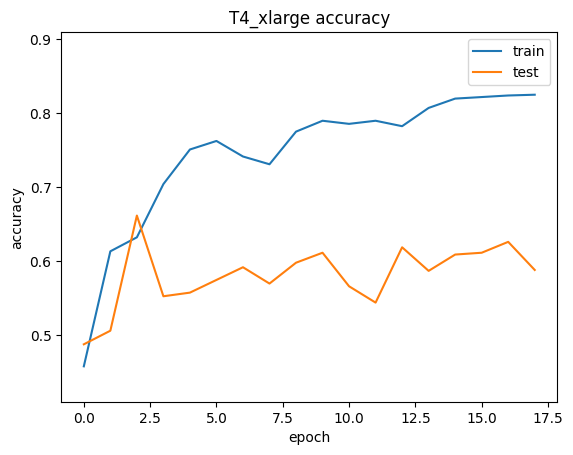

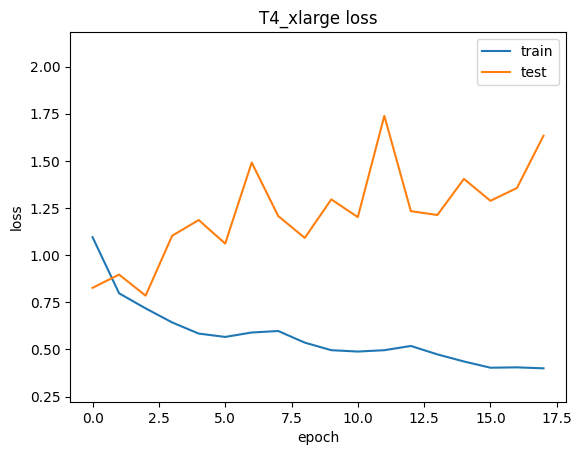

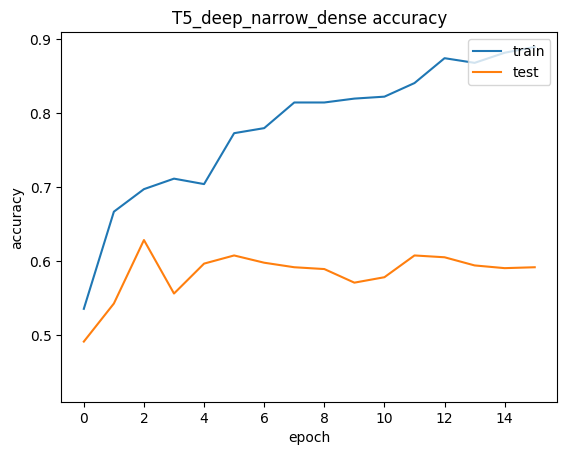

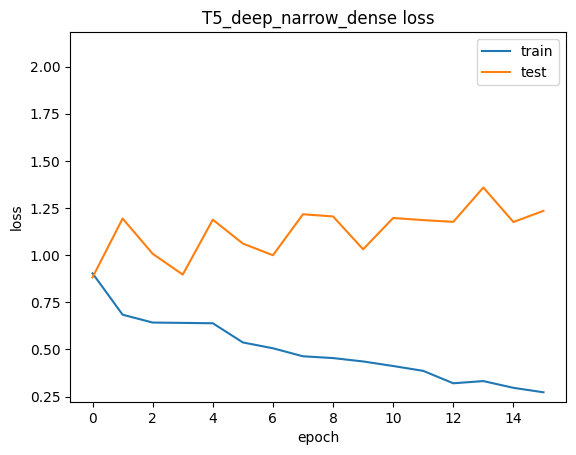

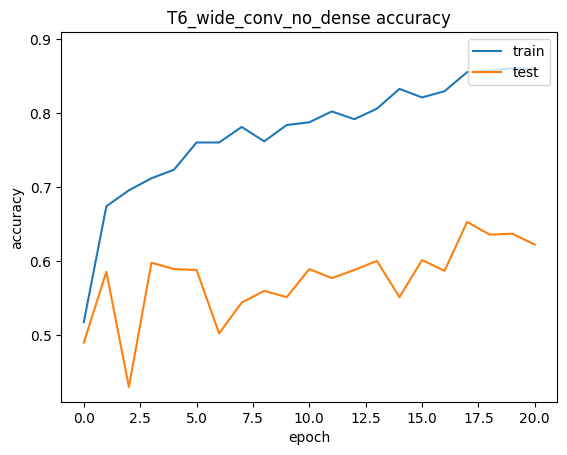

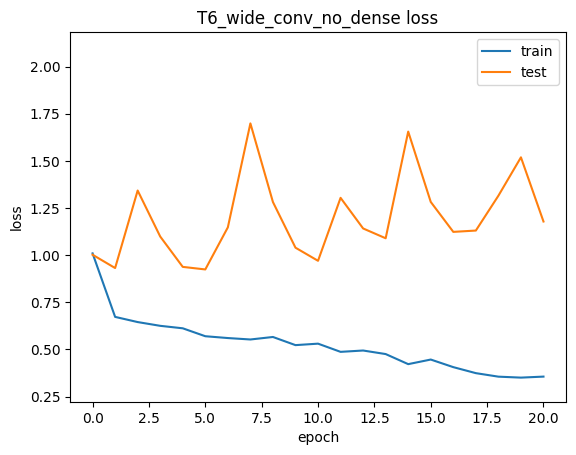

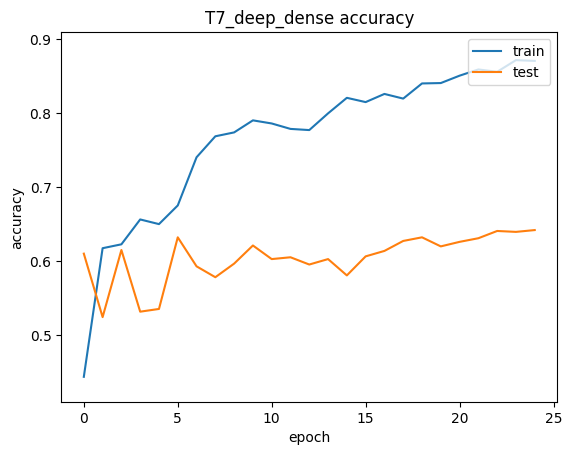

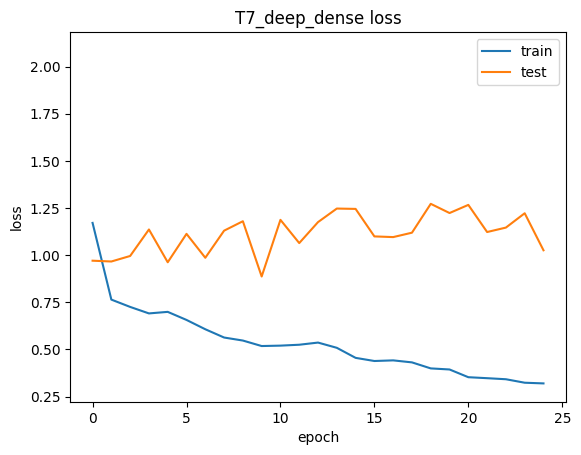

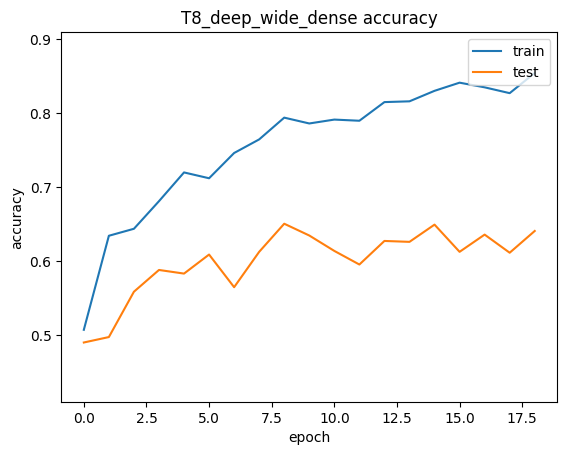

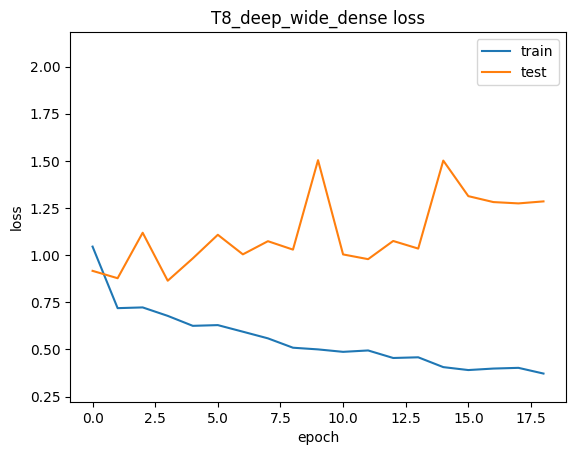

In [5]:
topologies = [
    {"name": "T1_small",  "conv_filters": [16, 32],       "dense_units": [64]},
    {"name": "T2_medium", "conv_filters": [32, 64],       "dense_units": [128]},
    {"name": "T3_large",  "conv_filters": [32, 64, 128],  "dense_units": [128, 64]},
    {"name": "T4_xlarge", "conv_filters": [64, 128, 256], "dense_units": [256, 128]},
    {"name": "T5_deep_narrow_dense", "conv_filters": [16, 32, 64, 128], "dense_units": [32]},
    {"name": "T6_wide_conv_no_dense", "conv_filters": [32, 64, 128],    "dense_units": []},
    {"name": "T7_deep_dense",      "conv_filters": [32, 64, 128], "dense_units": [128, 64, 32]},
    {"name": "T8_deep_wide_dense", "conv_filters": [32, 64, 128], "dense_units": [512, 256, 128]},
]

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_delta=1e-3,
    cooldown=3,        
    min_lr=1e-6,
    verbose=0)

# num_classes = 3
topo_results, histories = [], {}

# train all topologies
for t in topologies:
    model = Sequential()
    first = True
    for f in t["conv_filters"]:
        if first:
            model.add(Conv2D(f, (3, 3), activation='relu', input_shape=(w, h, 3)))
            first = False
        else:
            model.add(Conv2D(f, (3, 3), activation='relu'))
        model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    for u in t["dense_units"]:
        model.add(Dense(u, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])
    results = model.fit(train_gen, validation_data=val_gen, epochs=500,
                        verbose=1, callbacks=[reduce_lr, early_stopping])
    histories[t["name"]] = results.history

    
    val_gen.reset(); val_loss, val_acc = model.evaluate(val_gen, verbose=0)
    val_gen.reset(); y_pred = model.predict(val_gen).argmax(axis=1)
    best_epoch = int(np.argmin(results.history['val_loss'])) + 1
    topo_results.append({
        "name": t["name"],
        "params": model.count_params(),
        "val_loss": round(val_loss, 4),
        "val_acc":  round(val_acc, 4),
        "epochs":   best_epoch,
    })
    print(f">> {t['name']}: val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

all_acc  = [v for h in histories.values() for v in (h['acc'] + h['val_acc'])]
all_loss = [v for h in histories.values() for v in (h['loss'] + h['val_loss'])]

acc_lo  = max(0.0, min(all_acc) - 0.02)
acc_hi  = min(1.0, max(all_acc) + 0.02)
loss_lo = max(0.0, min(all_loss) - 0.05)
loss_hi = max(all_loss) + 0.05

# plot everything on the same scale
for name, hist in histories.items():
    plt.plot(hist['acc'])
    plt.plot(hist['val_acc'])
    plt.title(f'{name} accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.ylim(acc_lo, acc_hi)  
    plt.legend(['train', 'test'], loc='upper right')
    plt.show()

    plt.plot(hist['loss'])
    plt.plot(hist['val_loss'])
    plt.title(f'{name} loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.ylim(loss_lo, loss_hi) 
    plt.legend(['train', 'test'], loc='upper right')
    plt.show()

### Network Results:
- 8 Topologies have been tested
- T1_small:  conv_filters: [16, 32] & dense_units: [64]. Shows the best generalization among the models. The validation accuracy closely followed the training accuracy with a relatively small train-val gap, and the validation loss remained more stable than the other models. Although T1 didn't achieve the highest val accuracy, its learning curves indicate the least overfitting, hence the preferred model for a real world generalization.

- T2_medium conv_filters: [32, 64] & dense_units: [128]. T2 learned the training data, however is showing signs of overfitting. Even though the training accuracy improved steadily, the validation loss increased as training progressed, meaning the model did not generalize as well as T1.

- T3_large conv_filters: [32, 64, 128] &  dense_units: [128, 64]. T3 got strong training performance and high validation accuracy, but the validation learning curves were noisy. The fluctuations in validation accuracy and the increasing validation loss lead us to assume inconsistent generalization.

- T4_xlarge conv_filters: [64, 128, 256] & dense_units: [256, 128]. T4 showed good learning on the training data but experienced noticeable overfitting. The widening gap between train and val accuracy and the diverging val loss indicate poor generalization.

- T5_deep_narrow_dense conv_filters: [16, 32, 64, 128] & dense_units: [32]. T5 was good on training data but also generalized poorly. The validation accuracy remainded relatively low and the val loss also had signs of diverging, though the val loss was not as bad as T4.

- T6_wide_conv_no_dense conv_filters: [32, 64, 128] &    dense_units: []. T6 had good training performance but validation curves were noisy and inconsitent.

- T7_deep_dense  conv_filters: [32, 64, 128] & dense_units: [128, 64, 32]. T7 Training curves achieved very strong performance, but the val curves did not keep up as much which showed signs of overfitting.

- T8_deep_wide_dense conv_filters: [32, 64, 128] & dense_units: [512, 256, 128]. T8 had very reasonable training, but validation loss let it down and started diverging.

Conclusion: 
Even though T3 & T4 had higher peak val accuracy T1 was selected because it showed best balance of performance and generalization. Its train and validation curves remained relatively close throughout the training and the validation loss was more stable than those in larger models.

## Kernel Exploration

Epoch 1/500


2026-07-26 23:13:43.357861: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


60/60 [==============================] - ETA: 0s - loss: 1.5694 - acc: 0.4186

2026-07-26 23:14:03.251742: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


60/60 [==============================] - 22s 345ms/step - loss: 1.5694 - acc: 0.4186 - val_loss: 1.0890 - val_acc: 0.3627 - lr: 0.0010
Epoch 2/500
60/60 [==============================] - 20s 336ms/step - loss: 0.9488 - acc: 0.5289 - val_loss: 0.8451 - val_acc: 0.6164 - lr: 0.0010
Epoch 3/500
60/60 [==============================] - 20s 341ms/step - loss: 0.7086 - acc: 0.6822 - val_loss: 1.0350 - val_acc: 0.6103 - lr: 0.0010
Epoch 4/500
60/60 [==============================] - 20s 341ms/step - loss: 0.6225 - acc: 0.7258 - val_loss: 0.9963 - val_acc: 0.6593 - lr: 0.0010
Epoch 5/500
60/60 [==============================] - 20s 341ms/step - loss: 0.6015 - acc: 0.7447 - val_loss: 1.1510 - val_acc: 0.5907 - lr: 0.0010
Epoch 6/500
60/60 [==============================] - 20s 338ms/step - loss: 0.5896 - acc: 0.7426 - val_loss: 1.0006 - val_acc: 0.5944 - lr: 0.0010
Epoch 7/500
60/60 [==============================] - 21s 344ms/step - loss: 0.5440 - acc: 0.7847 - val_loss: 1.0386 - val_acc: 0.5

...

60/60 [==============================] - ETA: 0s - loss: 1.3088 - acc: 0.4270

2026-07-26 23:27:53.498861: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


60/60 [==============================] - 23s 343ms/step - loss: 1.3088 - acc: 0.4270 - val_loss: 1.0881 - val_acc: 0.4412 - lr: 0.0010
Epoch 2/500
60/60 [==============================] - 20s 342ms/step - loss: 1.0824 - acc: 0.4412 - val_loss: 1.0778 - val_acc: 0.4412 - lr: 0.0010
Epoch 3/500
60/60 [==============================] - 20s 333ms/step - loss: 1.0756 - acc: 0.4412 - val_loss: 1.0733 - val_acc: 0.4412 - lr: 0.0010
Epoch 4/500
60/60 [==============================] - 20s 338ms/step - loss: 1.0725 - acc: 0.4412 - val_loss: 1.0716 - val_acc: 0.4412 - lr: 0.0010
Epoch 5/500
60/60 [==============================] - 20s 332ms/step - loss: 1.0716 - acc: 0.4412 - val_loss: 1.0713 - val_acc: 0.4412 - lr: 0.0010
Epoch 6/500
60/60 [==============================] - 20s 335ms/step - loss: 1.0714 - acc: 0.4412 - val_loss: 1.0712 - val_acc: 0.4412 - lr: 0.0010
Epoch 7/500
60/60 [==============================] - 20s 340ms/step - loss: 1.0714 - acc: 0.4412 - val_loss: 1.0712 - val_acc: 0.4

2026-07-26 23:35:43.425415: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]
2026-07-26 23:35:45.411048: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


26/26 [==============================] - 2s 81ms/step
>> K3_kernel7: val_loss=1.0712 val_acc=0.4412


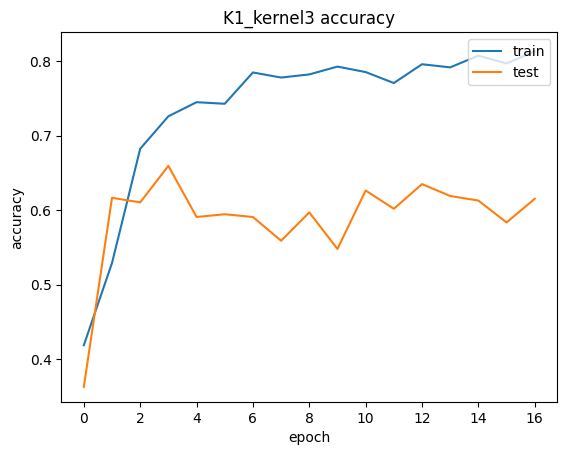

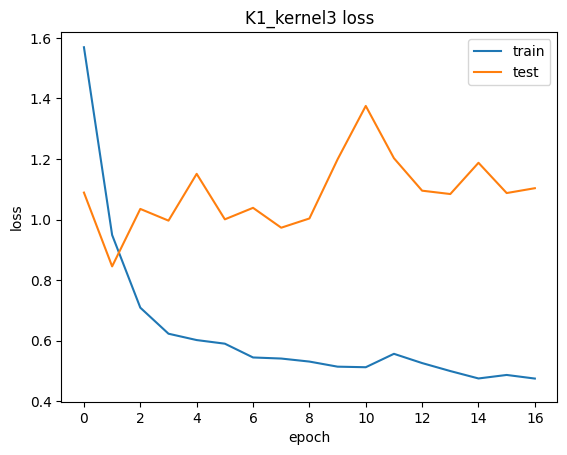

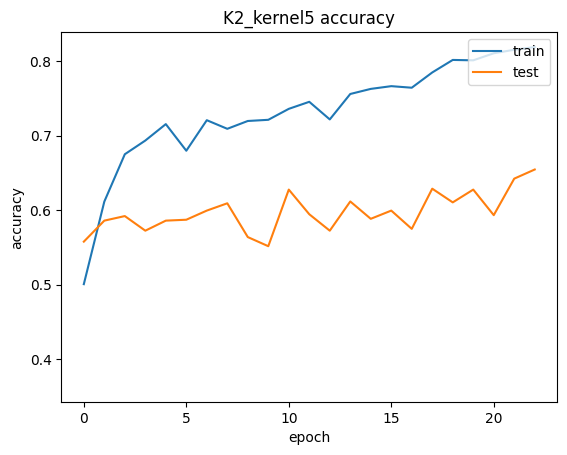

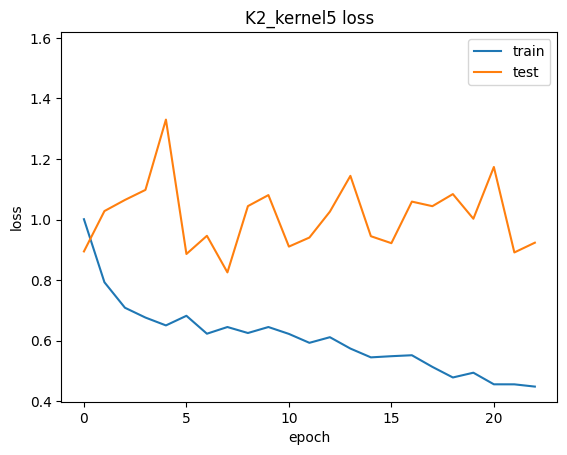

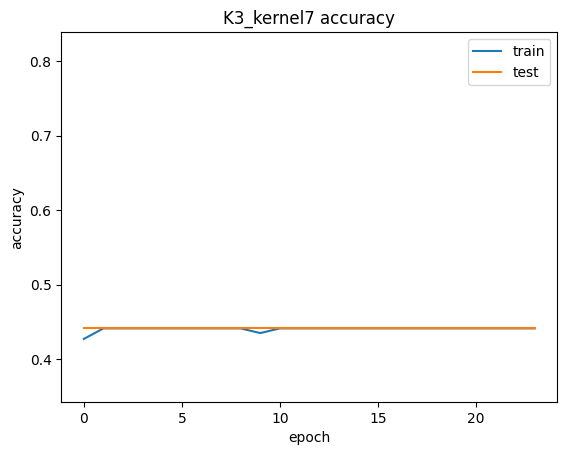

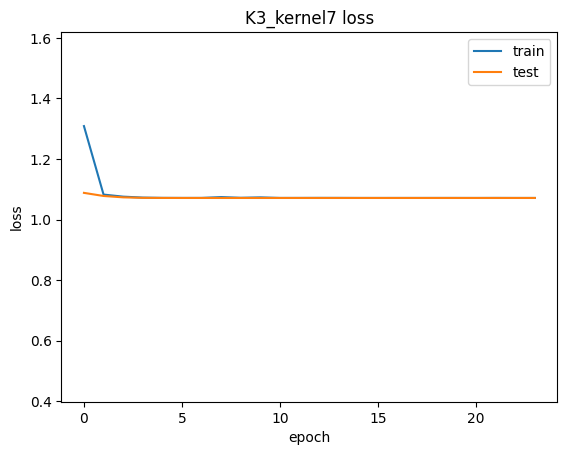

In [6]:
# Kernel exploration, BEST topology net: "name": "T6_wide_conv_no_dense", "conv_filters": [32, 64, 128],    "dense_units": []

BEST_CONV  = [16, 32]
BEST_DENSE = [64]

topologies = [
    {"name": "K1_kernel3", "conv_filters": BEST_CONV, "dense_units": BEST_DENSE, "kernel": 3},
    {"name": "K2_kernel5", "conv_filters": BEST_CONV, "dense_units": BEST_DENSE, "kernel": 5},
    {"name": "K3_kernel7", "conv_filters": BEST_CONV, "dense_units": BEST_DENSE, "kernel": 7},
]

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_delta=1e-3,
    cooldown=3,        
    min_lr=1e-6,
    verbose=1)

topo_results, histories = [], {}

# train all topologies
for t in topologies:
    model = Sequential()
    first = True
    for f in t["conv_filters"]:
        k = t.get("kernel", 3)          
        if first:
            model.add(Conv2D(f, (k, k), activation='relu', input_shape=(w, h, 3)))
            first = False
        else:
            model.add(Conv2D(f, (k, k), activation='relu'))
        model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    for u in t["dense_units"]:
        model.add(Dense(u, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])
    results = model.fit(train_gen, validation_data=val_gen, epochs=500,
                        verbose=1, callbacks=[reduce_lr, early_stopping])
    histories[t["name"]] = results.history

    # --- objective metrics at the RESTORED best-weights epoch ---
    val_gen.reset(); val_loss, val_acc = model.evaluate(val_gen, verbose=0)
    val_gen.reset(); y_pred = model.predict(val_gen).argmax(axis=1)
    best_epoch = int(np.argmin(results.history['val_loss'])) + 1
    topo_results.append({
        "name": t["name"],
        "params": model.count_params(),
        "val_loss": round(val_loss, 4),
        "val_acc":  round(val_acc, 4),
        "epochs":   best_epoch,
    })
    print(f">> {t['name']}: val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

all_acc  = [v for h in histories.values() for v in (h['acc'] + h['val_acc'])]
all_loss = [v for h in histories.values() for v in (h['loss'] + h['val_loss'])]

acc_lo  = max(0.0, min(all_acc) - 0.02)
acc_hi  = min(1.0, max(all_acc) + 0.02)
loss_lo = max(0.0, min(all_loss) - 0.05)
loss_hi = max(all_loss) + 0.05

# plot everything on the same scale
for name, hist in histories.items():
    plt.plot(hist['acc'])
    plt.plot(hist['val_acc'])
    plt.title(f'{name} accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.ylim(acc_lo, acc_hi)  
    plt.legend(['train', 'test'], loc='upper right')
    plt.show()

    plt.plot(hist['loss'])
    plt.plot(hist['val_loss'])
    plt.title(f'{name} loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.ylim(loss_lo, loss_hi) 
    plt.legend(['train', 'test'], loc='upper right')
    plt.show()

### Kernel Exploration Result:
- K1 (3x3): It shows strong learning capacity, with the training curves being very strong throughout the epochs. This however, is negated by the divergence between train and validation loss, which would indicate over fitting. While the model got a reasonable val acc, especially compared to what the others models have shown thus far, the increasing val loss seems to have capped the limit of what the model is seeing and hence the model was more confident on incorrect predictions on the validation (unseen) data. Therefore, K1 has learned something from the data, but generalization is not at a desirable place.

- K2 (5x5): This models shows a much more improved generalization when compared to K1. Both train and val accuracy have an positive upward trend, implying that it maybe better at predicting unseen data as compared to K1.Even though the val loss has noise, we believe this would be normal in our goal of optimization of the network. Val loss may not have been the best loss ever seen, though it did seem controlled and did not exhibit the same divergence behaviour seen in K1. K2 has achieved a better balance between learning the train data and optimizing for unseen. 5x5 kernel seems to be the best angle the model can look at the images from.

- K3 (7x7): K3 has shown significantly poorer performance when compared to the smaller kernels. The model seems to have failed learning meaningful feature representations from the input data and then plateaus. It seems 7x7 has reduced the effectiveness of feature extraction by losing the finer details within each slide, hence the poor convergence.

## Regularization Exploration

Epoch 1/500


2026-07-26 23:57:56.538713: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


60/60 [==============================] - ETA: 0s - loss: 1.5025 - acc: 0.4280

2026-07-26 23:58:16.067835: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


60/60 [==============================] - 22s 337ms/step - loss: 1.5025 - acc: 0.4280 - val_loss: 1.0931 - val_acc: 0.4424 - lr: 0.0010
Epoch 2/500
60/60 [==============================] - 21s 347ms/step - loss: 1.0802 - acc: 0.4422 - val_loss: 1.0755 - val_acc: 0.4804 - lr: 0.0010
Epoch 3/500
60/60 [==============================] - 20s 338ms/step - loss: 1.0360 - acc: 0.5305 - val_loss: 1.0885 - val_acc: 0.4436 - lr: 0.0010
Epoch 4/500
60/60 [==============================] - 20s 338ms/step - loss: 0.9338 - acc: 0.5662 - val_loss: 1.1011 - val_acc: 0.4730 - lr: 0.0010
Epoch 5/500
60/60 [==============================] - 20s 334ms/step - loss: 0.8931 - acc: 0.5688 - val_loss: 0.8898 - val_acc: 0.5588 - lr: 0.0010
Epoch 6/500
60/60 [==============================] - 20s 338ms/step - loss: 0.7594 - acc: 0.6266 - val_loss: 0.9350 - val_acc: 0.5809 - lr: 0.0010
Epoch 7/500
60/60 [==============================] - 20s 335ms/step - loss: 0.6723 - acc: 0.6901 - val_loss: 1.0058 - val_acc: 0.5

...

60/60 [==============================] - ETA: 0s - loss: 1.5186 - acc: 0.3845

2026-07-27 00:27:50.794999: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


60/60 [==============================] - 21s 334ms/step - loss: 1.5186 - acc: 0.3845 - val_loss: 0.9318 - val_acc: 0.4412 - lr: 0.0010
Epoch 2/500
60/60 [==============================] - 21s 344ms/step - loss: 0.9087 - acc: 0.5047 - val_loss: 0.9158 - val_acc: 0.5196 - lr: 0.0010
Epoch 3/500
60/60 [==============================] - 20s 338ms/step - loss: 0.8655 - acc: 0.5704 - val_loss: 0.8810 - val_acc: 0.5135 - lr: 0.0010
Epoch 4/500
60/60 [==============================] - 21s 345ms/step - loss: 0.8527 - acc: 0.5504 - val_loss: 0.8995 - val_acc: 0.4988 - lr: 0.0010
Epoch 5/500
60/60 [==============================] - 20s 339ms/step - loss: 0.8311 - acc: 0.5709 - val_loss: 0.9148 - val_acc: 0.4975 - lr: 0.0010
Epoch 6/500
60/60 [==============================] - 21s 343ms/step - loss: 0.8283 - acc: 0.5835 - val_loss: 0.8900 - val_acc: 0.5061 - lr: 0.0010
Epoch 7/500
60/60 [==============================] - 20s 341ms/step - loss: 0.8103 - acc: 0.5998 - val_loss: 0.9119 - val_acc: 0.4

2026-07-27 00:38:23.945650: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]
2026-07-27 00:38:26.094503: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


26/26 [==============================] - 2s 78ms/step
>> R5_dropout_and_noise: val_loss=0.8774 val_acc=0.5123


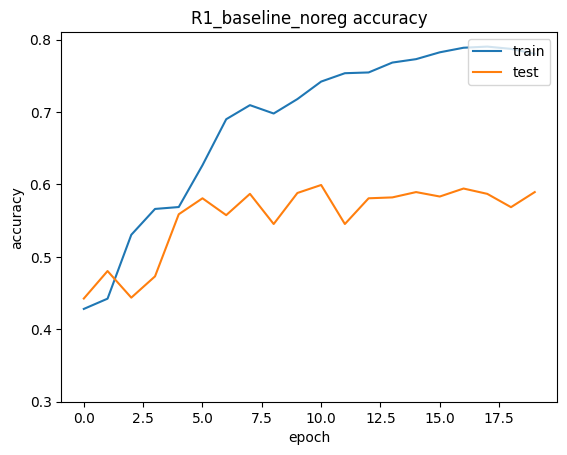

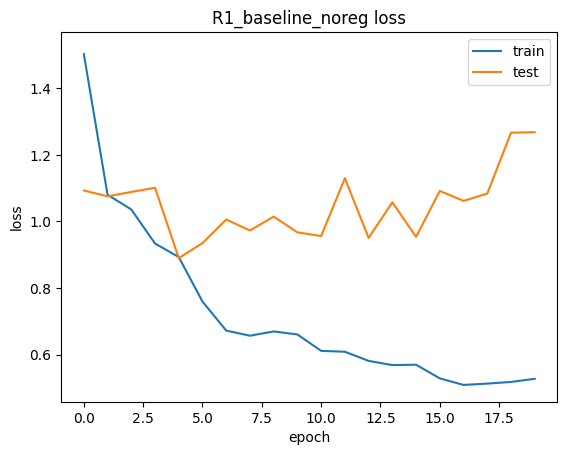

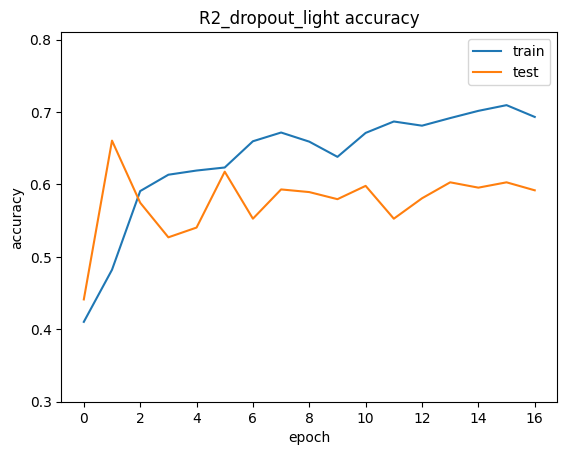

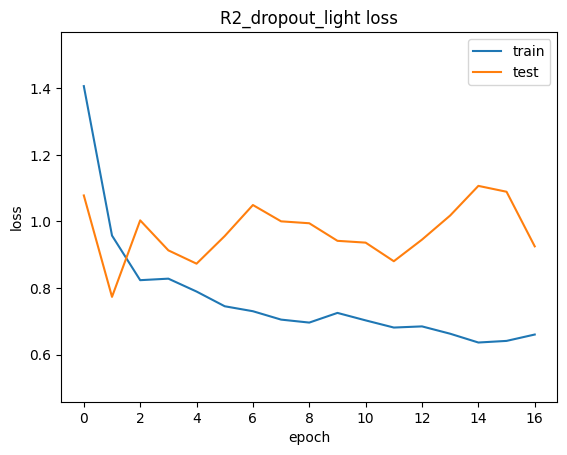

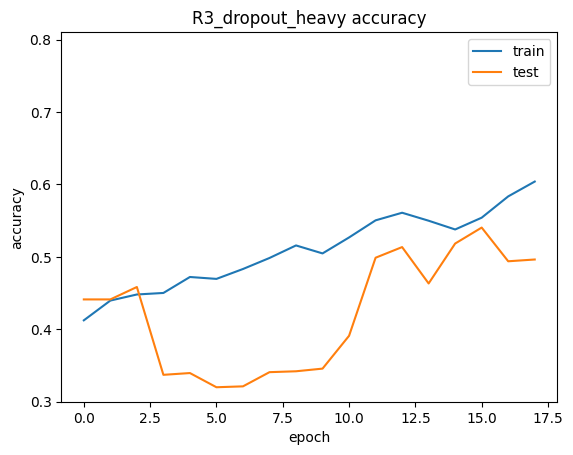

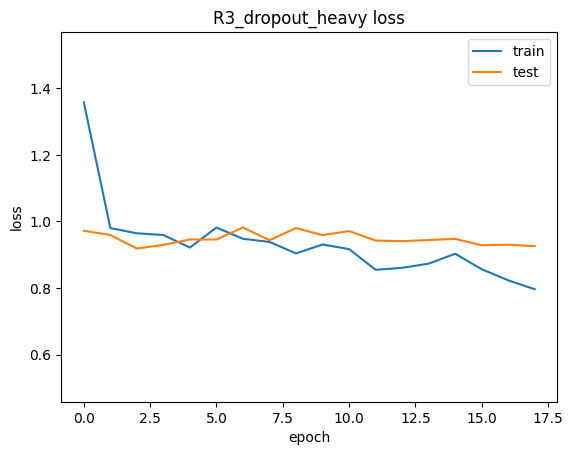

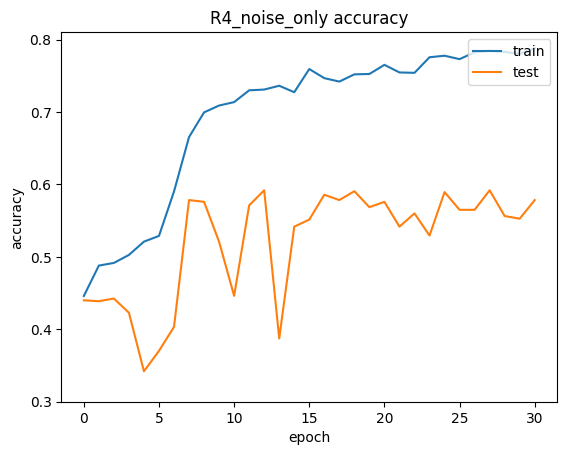

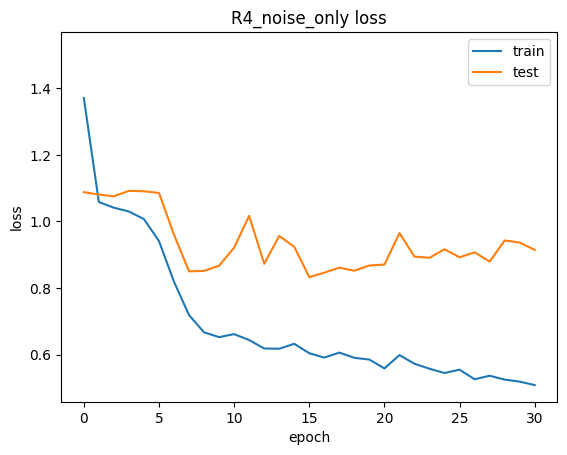

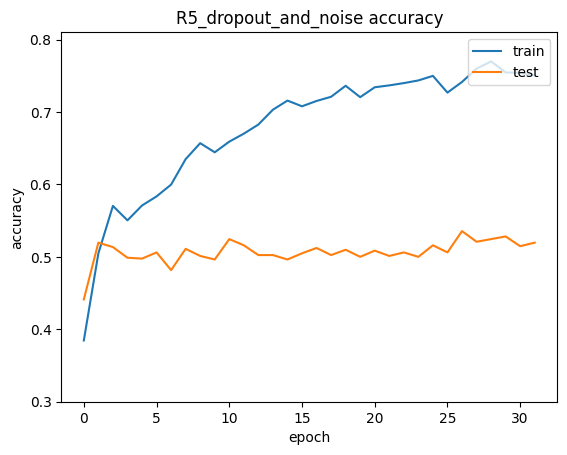

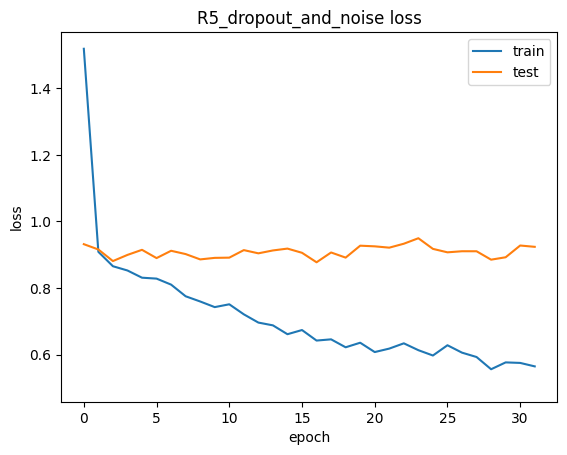

In [8]:
# regularization to try bring down the overfitting

from tensorflow.keras.layers import GaussianNoise, Dropout, SpatialDropout2D

# Regularization exploration: dropout vs noise, BEST topology net: T5_deep_narrow_dense
BEST_CONV  = [16, 32]
BEST_DENSE = [64]

topologies = [
    {"name": "R1_baseline_noreg",  "conv_filters": BEST_CONV, "dense_units": BEST_DENSE, "dropout": 0.0, "noise": 0.0, "kernel": 5},
    {"name": "R2_dropout_light",   "conv_filters": BEST_CONV, "dense_units": BEST_DENSE, "dropout": 0.2, "noise": 0.0, "kernel": 5},
    {"name": "R3_dropout_heavy",   "conv_filters": BEST_CONV, "dense_units": BEST_DENSE, "dropout": 0.5, "noise": 0.0, "kernel": 5},
    {"name": "R4_noise_only",      "conv_filters": BEST_CONV, "dense_units": BEST_DENSE, "dropout": 0.0, "noise": 0.1, "kernel": 5},
    {"name": "R5_dropout_and_noise","conv_filters": BEST_CONV, "dense_units": BEST_DENSE, "dropout": 0.2, "noise": 0.1, "kernel": 5},
]

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_delta=1e-3,
    cooldown=3,        
    min_lr=1e-6,
    verbose=1)

# num_classes = 3
topo_results, histories = [], {}

for t in topologies:
    model = Sequential()
    noise_std = t.get("noise", 0.0)
    dropout_rate = t.get("dropout", 0.0)
    k = t.get("kernel", 3)

    first = True
    for f in t["conv_filters"]:
        if first:
            # noise applied to the raw (rescaled) input, before the first conv
            model.add(GaussianNoise(noise_std, input_shape=(w, h, 3)))
            model.add(Conv2D(f, (k, k), activation='relu'))
            first = False
        else:
            model.add(Conv2D(f, (k, k), activation='relu'))
        model.add(MaxPooling2D((2, 2)))
        if dropout_rate > 0:
            model.add(SpatialDropout2D(dropout_rate))

    model.add(Flatten())
    for u in t["dense_units"]:
        model.add(Dense(u, activation='relu'))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))
    if not t["dense_units"] and dropout_rate > 0:
        model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])

    results = model.fit(train_gen, validation_data=val_gen, epochs=500,
                        verbose=1, callbacks=[reduce_lr, early_stopping])
    histories[t["name"]] = results.history

    val_gen.reset(); val_loss, val_acc = model.evaluate(val_gen, verbose=0)
    val_gen.reset(); y_pred = model.predict(val_gen).argmax(axis=1)
    best_epoch = int(np.argmin(results.history['val_loss'])) + 1
    topo_results.append({
        "name": t["name"],
        "params": model.count_params(),
        "val_loss": round(val_loss, 4),
        "val_acc":  round(val_acc, 4),
        "epochs":   best_epoch,
    })
    print(f">> {t['name']}: val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

all_acc  = [v for hist in histories.values() for v in (hist['acc'] + hist['val_acc'])]
all_loss = [v for hist in histories.values() for v in (hist['loss'] + hist['val_loss'])]

acc_lo  = max(0.0, min(all_acc) - 0.02)
acc_hi  = min(1.0, max(all_acc) + 0.02)
loss_lo = max(0.0, min(all_loss) - 0.05)
loss_hi = max(all_loss) + 0.05

# plot everything on the same scale
for name, hist in histories.items():
    plt.plot(hist['acc'])
    plt.plot(hist['val_acc'])
    plt.title(f'{name} accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.ylim(acc_lo, acc_hi)  
    plt.legend(['train', 'test'], loc='upper right')
    plt.show()

    plt.plot(hist['loss'])
    plt.plot(hist['val_loss'])
    plt.title(f'{name} loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.ylim(loss_lo, loss_hi) 
    plt.legend(['train', 'test'], loc='upper right')
    plt.show()

### Regularization Exploration Results:
- R1: Strong train curves (train acc improves consistently and train loss continues decreasing). Validation accuracy initally improves but then reaches a plateau and the gap between the accuracies increases. The val loss initially start well but then goes into diverging and doesn't recover. Learns well but doesn't generalize well.

- R2: Standard dropout applied. Train curves are quite strong. Val accuracy follows the train acc trend much more closely. The val loss is more stable and doesn't show strong divergence, there is still a gap but the trend isn't as noisy or wide. The train-test gap is smaller when compared with R1.

- R3: The train curves are the least strongest by this point, this is due to the heaviest amount of dropout being applied. The model is at the point of even being considered to have underfit.

- R4: Noise only. Very strong train curves. Val acc remains much lower and becomes noisy. The val loss begins to diverge. Noise alone is insufficient as a regularization strategy for this problem.

- R5: Very strong train curves. The Val curves seem to stagnate. Combining two regularization approaches seems to prevent generalization

Conclusion: The light dropout provided the most effective regularization.

## Most Appropriate Model

Epoch 1/500


2026-07-27 01:59:48.552239: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]
2026-07-27 01:59:49.082405: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_25/spatial_dropout2d_6/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


60/60 [==============================] - ETA: 0s - loss: 1.5061 - acc: 0.4259

2026-07-27 02:00:08.105720: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


60/60 [==============================] - 22s 338ms/step - loss: 1.5061 - acc: 0.4259 - val_loss: 0.9810 - val_acc: 0.5086 - lr: 0.0010
Epoch 2/500
60/60 [==============================] - 20s 332ms/step - loss: 0.9138 - acc: 0.5331 - val_loss: 0.9317 - val_acc: 0.5159 - lr: 0.0010
Epoch 3/500
60/60 [==============================] - 20s 341ms/step - loss: 0.8672 - acc: 0.5809 - val_loss: 0.9237 - val_acc: 0.4975 - lr: 0.0010
Epoch 4/500
60/60 [==============================] - 20s 340ms/step - loss: 0.8335 - acc: 0.6134 - val_loss: 0.9154 - val_acc: 0.5049 - lr: 0.0010
Epoch 5/500
60/60 [==============================] - 20s 340ms/step - loss: 0.7943 - acc: 0.6182 - val_loss: 0.8218 - val_acc: 0.5147 - lr: 0.0010
Epoch 6/500
60/60 [==============================] - 20s 337ms/step - loss: 0.8181 - acc: 0.6113 - val_loss: 0.9044 - val_acc: 0.5135 - lr: 0.0010
Epoch 7/500
60/60 [==============================] - 20s 339ms/step - loss: 0.7988 - acc: 0.6066 - val_loss: 0.8857 - val_acc: 0.4

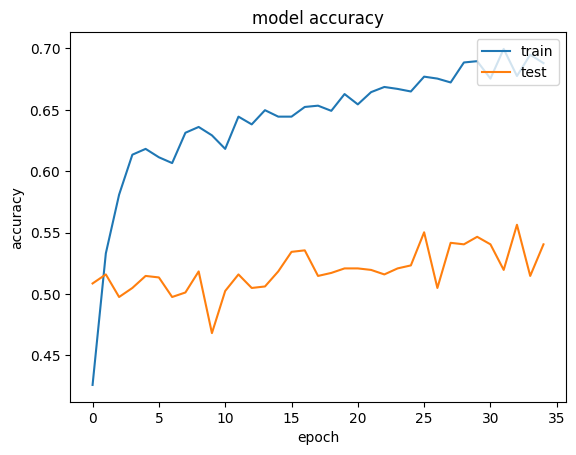

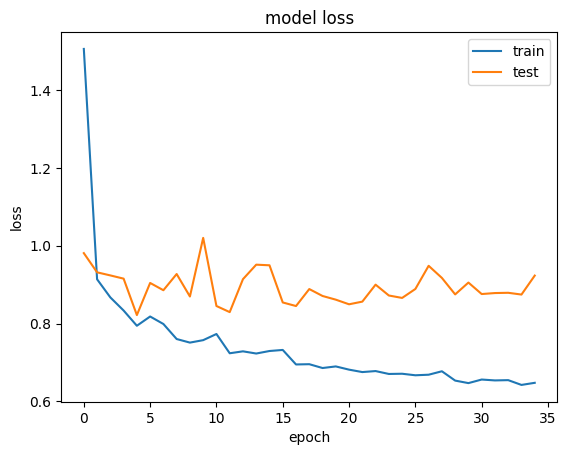

In [9]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_delta=1e-3,
    cooldown=3,
    min_lr=1e-6,
    verbose=1
)

modelBest = Sequential()
modelBest.add(Conv2D(16,(5,5),activation='relu', input_shape=(w,h,3)))
modelBest.add(MaxPooling2D((2,2)))
modelBest.add(SpatialDropout2D(0.2))
modelBest.add(Conv2D(32,(5,5),activation='relu'))
modelBest.add(MaxPooling2D((2,2)))
modelBest.add(SpatialDropout2D(0.2))

modelBest.add(Flatten())
modelBest.add(Dense(64,activation='relu'))
modelBest.add(Dropout(0.2))
modelBest.add(Dense(num_classes,activation='softmax'))

modelBest.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])

# Fit the model
results = modelBest.fit(train_gen, validation_data=val_gen, epochs=500, verbose=1, callbacks=[reduce_lr, early_stopping])


plt.plot(results.history['acc'])
plt.plot(results.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()



plt.plot(results.history['loss'])
plt.plot(results.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

- The model was formed based on the best params from the previouse explorations.
- The resulting model has very strong train curves. The val curves do leave more to be desired. The val loss is not bad, it does show signs of diverging but not such an alarm amount. Val acc is not very close to the train acc, however, it is steadily climbing, it is not stagnat, regardless of all the noise present, it does show signs of some growth

## Model Evaluation

2026-07-27 02:17:30.037254: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


26/26 [==============================] - 2s 76ms/step
Class mapping: {'Healthy': 0, 'aculus_olearius': 1, 'olive_peacock_spot': 2}

== Validation Confusion Matrix ==
[[248   0   1]
 [196   1  10]
 [189   0 171]]

== Per-Class Metrics ==
Class                   Precision  Sensitivity  Specificity  Support
Healthy                    39.18%       99.60%       32.10%      249
aculus_olearius           100.00%        0.48%      100.00%      207
olive_peacock_spot         93.96%       47.50%       97.59%      360

Overall Accuracy: 51.47 %

== Classification Report ==
                    precision    recall  f1-score   support

           Healthy      0.392     0.996     0.562       249
   aculus_olearius      1.000     0.005     0.010       207
olive_peacock_spot      0.940     0.475     0.631       360

          accuracy                          0.515       816
         macro avg      0.777     0.492     0.401       816
      weighted avg      0.788     0.515     0.452       816



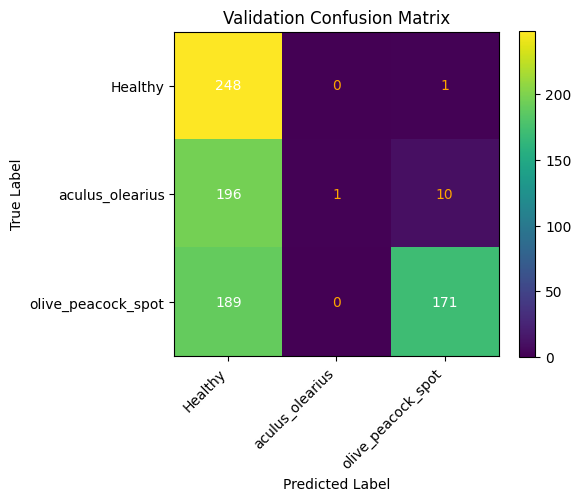

In [11]:
# Evaluate Best Model

# Based on my research it resets the val gen and makes it start from the top
val_gen.reset()

# Predict validation data
y_pred = modelBest.predict(
    val_gen,
    steps=len(val_gen),
    verbose=1
)

# Convert predicted probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Get true labels from val_gen (already integer class indices)
y_true = val_gen.classes

# Make sure both arrays are the same length
y_true = y_true[:len(y_pred_classes)]

print("Class mapping:", val_gen.class_indices)


# Confusion Matrix
overall_cm = confusion_matrix(
    y_true,
    y_pred_classes,
    labels=np.arange(num_classes)
)

print("\n== Validation Confusion Matrix ==")
print(overall_cm)


# Per-Class Metrics (one-vs-rest)
print("\n== Per-Class Metrics ==")
print(f"{'Class':<22}{'Precision':>11}{'Sensitivity':>13}{'Specificity':>13}{'Support':>9}")

for i, name in enumerate(CLASSES):
    tp = overall_cm[i, i]
    fn = overall_cm[i, :].sum() - tp
    fp = overall_cm[:, i].sum() - tp
    tn = overall_cm.sum() - tp - fp - fn

    precision   = tp / (tp + fp) if (tp + fp) else 0
    sensitivity = tp / (tp + fn) if (tp + fn) else 0
    specificity = tn / (tn + fp) if (tn + fp) else 0

    print(f"{name:<22}{precision*100:>10.2f}%{sensitivity*100:>12.2f}%"
          f"{specificity*100:>12.2f}%{tp+fn:>9}")

accuracy = np.trace(overall_cm) / overall_cm.sum()
print(f"\nOverall Accuracy: {accuracy * 100:.2f} %")


# Classification Report
print("\n== Classification Report ==")
print(classification_report(y_true, y_pred_classes,
                            target_names=CLASSES, digits=3))


# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
plt.imshow(overall_cm, interpolation='nearest')
plt.title('Validation Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, CLASSES, rotation=45, ha='right')
plt.yticks(tick_marks, CLASSES)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add numbers inside matrix
for i in range(overall_cm.shape[0]):
    for j in range(overall_cm.shape[1]):
        plt.text(
            j, i, overall_cm[i, j],
            ha='center',
            va='center',
            color='white' if overall_cm[i, j] > overall_cm.max() / 2 else 'orange'
        )

plt.tight_layout()
plt.show()

In [12]:
train_eval_gen = val_datagen.flow_from_directory('train', target_size=(w, h),
                     batch_size=32, class_mode='categorical', classes=CLASSES,
                     subset='training', shuffle=False, seed=SEED)

train_eval_gen.reset()
y_pred_classes = np.argmax(modelBest.predict(train_eval_gen, verbose=0), axis=1)
y_true = train_eval_gen.classes[:len(y_pred_classes)]
print(confusion_matrix(y_true, y_pred_classes, labels=np.arange(num_classes)))
print(classification_report(y_true, y_pred_classes, target_names=CLASSES, digits=3))

Found 1904 images belonging to 3 classes.


2026-07-27 02:22:05.110196: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


[[556   1  24]
 [405   4  74]
 [165   3 672]]
                    precision    recall  f1-score   support

           Healthy      0.494     0.957     0.651       581
   aculus_olearius      0.500     0.008     0.016       483
olive_peacock_spot      0.873     0.800     0.835       840

          accuracy                          0.647      1904
         macro avg      0.622     0.588     0.501      1904
      weighted avg      0.663     0.647     0.571      1904



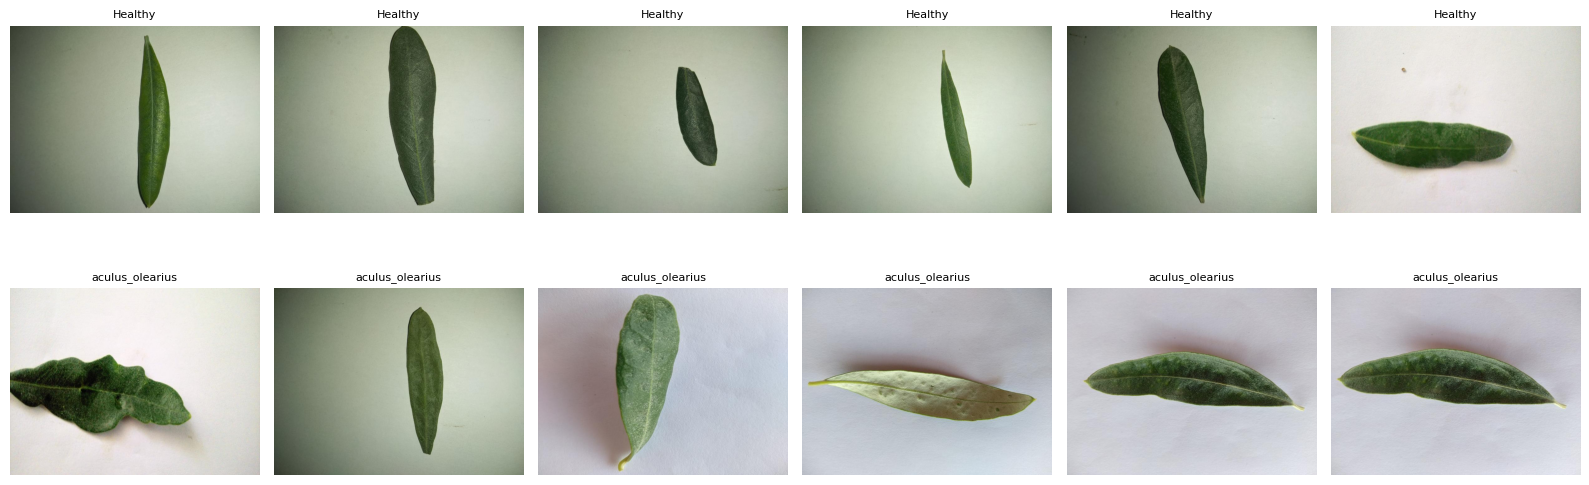

In [13]:
import glob
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for row, cls in enumerate(['Healthy', 'aculus_olearius']):
    for col, f in enumerate(sorted(glob.glob(f'train/{cls}/*'))[:6]):
        axes[row, col].imshow(plt.imread(f))
        axes[row, col].set_title(cls, fontsize=8); axes[row, col].axis('off')
plt.tight_layout(); plt.show()

# Transfer learning test

In [14]:
from tensorflow.keras.applications.densenet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10, horizontal_flip=True, vertical_flip=True,
    validation_split=0.3)
val_datagen  = ImageDataGenerator(
    preprocessing_function=preprocess_input, validation_split=0.3)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory('train', target_size=(w, h),
                batch_size=32, class_mode='categorical', classes=CLASSES,
                subset='training', shuffle=True, seed=SEED)
val_gen   = val_datagen.flow_from_directory('train', target_size=(w, h),
                batch_size=32, class_mode='categorical', classes=CLASSES,
                subset='validation', shuffle=False, seed=SEED)
test_gen  = test_datagen.flow_from_directory('test', target_size=(w, h),
                batch_size=32, class_mode='categorical', classes=CLASSES,
                shuffle=False, seed=SEED)

Found 1904 images belonging to 3 classes.
Found 816 images belonging to 3 classes.
Found 680 images belonging to 3 classes.


In [17]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

tf.keras.utils.set_random_seed(SEED)

base = DenseNet121(weights='imagenet', include_top=False,
                   input_shape=(w, h, 3), pooling='avg')
base.trainable = False

modelTL = Sequential()
modelTL.add(base)
modelTL.add(Dropout(0.3))
modelTL.add(Dense(num_classes, activation='softmax'))

modelTL.compile(loss='categorical_crossentropy',
                optimizer=tf.keras.optimizers.Adam(1e-3), metrics=['acc'])
modelTL.summary()

y  = train_gen.classes
cw = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weight = dict(enumerate(cw))

29084464/29084464 [==============================] - 1s 0us/step
Model: "sequential_26"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 densenet121 (Functional)    (None, 1024)              7037504   
                                                                 
 dropout_4 (Dropout)         (None, 1024)              0         
                                                                 
 dense_61 (Dense)            (None, 3)                 3075      
                                                                 
Total params: 7,040,579
Trainable params: 3,075
Non-trainable params: 7,037,504
_________________________________________________________________


In [18]:
es1 = EarlyStopping(monitor='val_loss', patience=8,
                    restore_best_weights=True, verbose=1)

hist1 = modelTL.fit(train_gen, validation_data=val_gen, epochs=30,
                    class_weight=class_weight, callbacks=[es1], verbose=1)

Epoch 1/30


2026-07-27 02:34:58.332662: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


60/60 [==============================] - ETA: 0s - loss: 0.8926 - acc: 0.6071

2026-07-27 02:35:22.267047: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


60/60 [==============================] - 28s 385ms/step - loss: 0.8926 - acc: 0.6071 - val_loss: 0.7876 - val_acc: 0.6838
Epoch 2/30
60/60 [==============================] - 22s 363ms/step - loss: 0.5013 - acc: 0.8036 - val_loss: 0.7026 - val_acc: 0.7145
Epoch 3/30
60/60 [==============================] - 21s 356ms/step - loss: 0.3672 - acc: 0.8734 - val_loss: 0.7021 - val_acc: 0.7377
Epoch 4/30
60/60 [==============================] - 22s 359ms/step - loss: 0.3097 - acc: 0.8887 - val_loss: 0.6641 - val_acc: 0.7488
Epoch 5/30
60/60 [==============================] - 21s 355ms/step - loss: 0.2810 - acc: 0.8997 - val_loss: 0.6107 - val_acc: 0.7635
Epoch 6/30
60/60 [==============================] - 22s 359ms/step - loss: 0.2572 - acc: 0.9128 - val_loss: 0.6747 - val_acc: 0.7488
Epoch 7/30
60/60 [==============================] - 22s 360ms/step - loss: 0.2312 - acc: 0.9223 - val_loss: 0.6567 - val_acc: 0.7549
Epoch 8/30
60/60 [==============================] - 22s 359ms/step - loss: 0.233

In [19]:
base.trainable = True

for layer in base.layers:
    # only the final dense block adapts; earlier features stay generic
    if not layer.name.startswith('conv5'):
        layer.trainable = False
    # keep BatchNorm in inference mode — critical
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

modelTL.compile(loss='categorical_crossentropy',
                optimizer=tf.keras.optimizers.Adam(1e-5), metrics=['acc'])

es2 = EarlyStopping(monitor='val_loss', patience=15,
                    restore_best_weights=True, verbose=1)
rl2 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                        min_lr=1e-8, verbose=1)

hist2 = modelTL.fit(train_gen, validation_data=val_gen, epochs=60,
                    class_weight=class_weight, callbacks=[rl2, es2], verbose=1)

Epoch 1/60


2026-07-27 02:48:44.187857: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


60/60 [==============================] - ETA: 0s - loss: 0.1367 - acc: 0.9564

2026-07-27 02:49:09.017254: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


60/60 [==============================] - 29s 278ms/step - loss: 0.1367 - acc: 0.9564 - val_loss: 0.5383 - val_acc: 0.8039 - lr: 1.0000e-05
Epoch 2/60
60/60 [==============================] - 22s 361ms/step - loss: 0.1430 - acc: 0.9480 - val_loss: 0.5731 - val_acc: 0.7966 - lr: 1.0000e-05
Epoch 3/60
60/60 [==============================] - 22s 360ms/step - loss: 0.1305 - acc: 0.9527 - val_loss: 0.6265 - val_acc: 0.7929 - lr: 1.0000e-05
Epoch 4/60
60/60 [==============================] - 22s 365ms/step - loss: 0.1214 - acc: 0.9564 - val_loss: 0.5632 - val_acc: 0.8039 - lr: 1.0000e-05
Epoch 5/60
60/60 [==============================] - 22s 362ms/step - loss: 0.1014 - acc: 0.9664 - val_loss: 0.6173 - val_acc: 0.7966 - lr: 1.0000e-05
Epoch 6/60
60/60 [==============================] - 22s 371ms/step - loss: 0.1127 - acc: 0.9617 - val_loss: 0.5346 - val_acc: 0.8186 - lr: 1.0000e-05
Epoch 7/60
60/60 [==============================] - 22s 362ms/step - loss: 0.0870 - acc: 0.9748 - val_loss: 0.6

In [22]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score

for split_name, gen in [('VALIDATION', val_gen), ('TEST', test_gen)]:
    gen.reset()
    y_pred = np.argmax(modelTL.predict(gen, steps=len(gen), verbose=0), axis=1)
    y_true = gen.classes[:len(y_pred)]

    print(f"\n{'='*50}\n{split_name}  ({len(y_true)} images)\n{'='*50}")
    print(confusion_matrix(y_true, y_pred, labels=np.arange(num_classes)))
    print(classification_report(y_true, y_pred, target_names=CLASSES, digits=3))
    print(f"macro-F1: {f1_score(y_true, y_pred, average='macro'):.3f}")

2026-07-27 02:56:33.175320: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]



VALIDATION  (816 images)
[[246   3   0]
 [ 11 190   6]
 [ 46  82 232]]
                    precision    recall  f1-score   support

           Healthy      0.812     0.988     0.891       249
   aculus_olearius      0.691     0.918     0.788       207
olive_peacock_spot      0.975     0.644     0.776       360

          accuracy                          0.819       816
         macro avg      0.826     0.850     0.819       816
      weighted avg      0.853     0.819     0.814       816

macro-F1: 0.819


2026-07-27 02:56:36.910555: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]



TEST  (680 images)
[[206   5   9]
 [  4 183  13]
 [  1   4 255]]
                    precision    recall  f1-score   support

           Healthy      0.976     0.936     0.956       220
   aculus_olearius      0.953     0.915     0.934       200
olive_peacock_spot      0.921     0.981     0.950       260

          accuracy                          0.947       680
         macro avg      0.950     0.944     0.946       680
      weighted avg      0.948     0.947     0.947       680

macro-F1: 0.946


# Model Save
<p><b>NB:</b> Allows us to always be able to pull the model, similar to a check point and run it without needing to train over and over</p>

In [20]:
# Saving the model
import time

ts = int(time.time())
file_path = f"productionModel/{ts}/"
modelBest.save(filepath=file_path, save_format='tf')

2026-07-27 02:56:27.294589: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,?,?,?]
	 [[{{node inputs}}]]
2026-07-27 02:56:27.324882: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,?,?,?]
	 [[{{node inputs}}]]
2026-07-27 02:56:27.471509: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,64]
	 [[{{node inputs}}]]
2026-07-27 02

INFO:tensorflow:Assets written to: productionModel/1785117387/assets


INFO:tensorflow:Assets written to: productionModel/1785117387/assets


In [21]:
ts = str(int(time.time()))
file_path = ts
modelBest.save(filepath=file_path, save_format='tf')

#creates a zip file which can be downloaded and unzipped
import shutil
shutil.make_archive(ts, 'zip', ts)

2026-07-27 02:56:28.580779: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,?,?,?]
	 [[{{node inputs}}]]
2026-07-27 02:56:28.611669: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,?,?,?]
	 [[{{node inputs}}]]
2026-07-27 02:56:28.768635: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,64]
	 [[{{node inputs}}]]
2026-07-27 02

INFO:tensorflow:Assets written to: 1785117388/assets


INFO:tensorflow:Assets written to: 1785117388/assets


'/home/a00049549/kq_tf/a00049549_CA3/1785117388.zip'